<a href="https://colab.research.google.com/github/assu786/MACHINE-LEARNING/blob/main/carprice_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
#load dataset
df=pd.read_csv('/content/car data.csv')
df.head()

,Car_Name,company,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,maruti suzuki,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,maruti suzuki,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,maruti suzuki,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,maruti suzuki,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,maruti suzuki,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [14]:
#drop car_name column
if 'Car_Name' in df.columns:
    df = df.drop('Car_Name', axis=1)
df.head()

,company,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,maruti suzuki,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,maruti suzuki,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,maruti suzuki,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,maruti suzuki,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,maruti suzuki,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [15]:
#convert categorical into numerical
df=pd.get_dummies(df,drop_first=True)
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,company_hero,company_honda,company_hyndai,company_maruti suzuki,company_other,company_toyota,company_tvs,company_yamaha,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,False,False,True,False,False,False,False,False,True,False,True
1,2013,4.75,9.54,43000,0,False,False,False,True,False,False,False,False,True,False,False,True
2,2017,7.25,9.85,6900,0,False,False,False,True,False,False,False,False,False,True,False,True
3,2011,2.85,4.15,5200,0,False,False,False,True,False,False,False,False,False,True,False,True
4,2014,4.60,6.87,42450,0,False,False,False,True,False,False,False,False,True,False,False,True


In [16]:
x=df.drop('Selling_Price',axis=1)
y=df['Selling_Price']

In [17]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
#train ml model random forest
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    random_state=42
)
model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [19]:
#evaluate model
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')


Mean Squared Error: 0.8497506011475404
Mean Absolute Error: 0.6083950819672135
R-squared: 0.9631113940087319


In [20]:
#create prediction function
def predict_car_price(year,
                      present_price,
                      km_driven,
                      owner,
                      company,
                      fuel_type,
                      seller_type,
                      transmission):
  input_data = pd.DataFrame({
      "Year":[year],
      "Present_Price": [present_price],
      "Kms_Driven": [km_driven],
      "Owner": [owner],
      "Fuel_Type_"+fuel_type:[True],
      "Company_"+company:[True],
      "Seller_Type"+seller_type:[True],
      "Transmission"+transmission:[True]
  })
  input_data=pd.get_dummies(input_data,drop_first=True)
  input_data=input_data.reindex(columns=x.columns,fill_value=0)
  prediction=model.predict(input_data)
  return prediction[0]


In [21]:
price=predict_car_price(
    year=2019,
    present_price=3.6,
    km_driven=20000,
    owner=1,
    company='Maruti',
    fuel_type='Petrol',
    seller_type='Individual',
    transmission='Manual'
)
print("pridicted selling price:",price)

pridicted selling price: 2.904000000000001


In [22]:
!pip install shap
import shap
shap.initjs()

In [23]:
#create shap explainer
explainer=shap.TreeExplainer(model)

In [25]:
#calculate SHAP values
shap_values=explainer.shap_values(x_train)

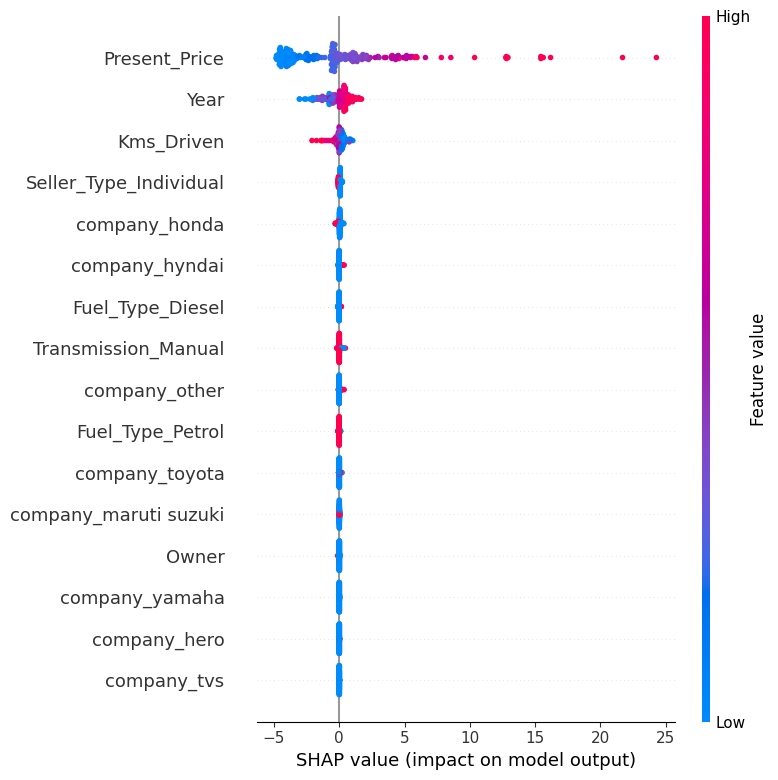

In [26]:
#global explaination
shap.summary_plot(shap_values,x_train)

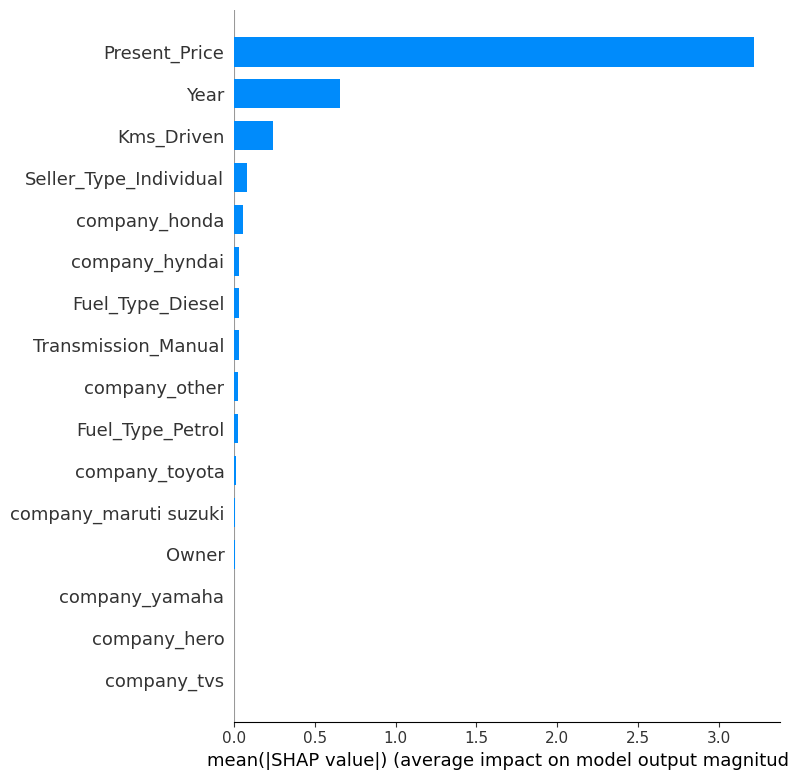

In [27]:
#bar plot
shap.summary_plot(shap_values,x_train,plot_type='bar')

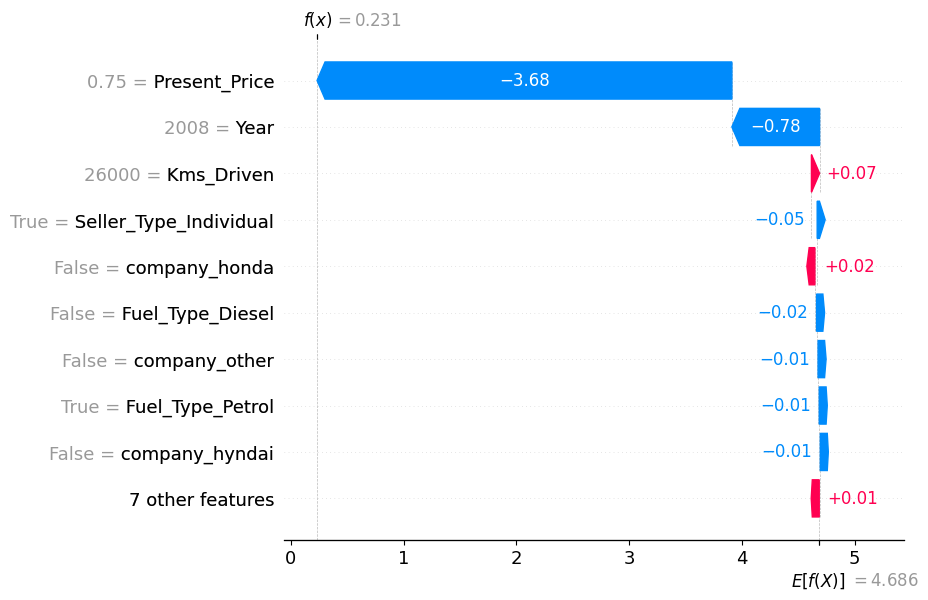

In [29]:
#waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=x_train.iloc[0],
        feature_names=x_train.columns
    )
)